In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import shap
import joblib
import scipy.stats as stats

sns.set(style="whitegrid")

In [ ]:
data = pd.read_csv('/content/final_trending_platform_dataset.csv')
print("Dataset Shape:", data.shape)
data.head()


Dataset Shape: (2373, 32)


,ID,Name,Age,Gender,Gadget_Name,Gadget_Checks_Per_Day,Apps_Used_Daily,Anxiety_Level,Depression_Level,Parental_Control,...,Coursera_Hours,Udemy_Hours,Google_Classroom_Hours,Khan_Academy_Hours,Byjus_Hours,Game_Hours,Educational_Game_Hours,Distraction_Level,Addiction_Level,Academic_Performance
0,3,Adrian Knox,13,Other,Smartwatch,137,8,2,3,0,...,0.09,0.00,0.10,0.03,0.18,0.96,0.54,Low,9.2,93
1,4,Brittany Hamilton,18,Female,Smartphone,128,7,9,10,0,...,0.00,0.00,0.11,0.21,0.48,0.00,0.25,Medium,9.8,78
2,5,Steven Smith,14,Other,Desktop,96,20,1,5,0,...,0.58,0.21,0.05,0.00,0.00,0.00,0.11,Low,8.6,56
3,6,Mary Adams,13,Female,Tablet,135,8,7,1,0,...,0.00,0.00,0.00,1.40,0.00,0.00,0.00,Low,8.8,89
4,7,Hailey Moses,16,Male,Laptop,129,9,6,7,0,...,1.00,0.00,0.00,0.00,0.00,0.36,2.11,Low,10.0,89


In [ ]:
print(data.info())
print("\nMissing Values (Before Handling):\n", data.isnull().sum())
print("\nUnique Values Per Column:\n", data.nunique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2373 entries, 0 to 2372
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      2373 non-null   int64  
 1   Name                    2373 non-null   object 
 2   Age                     2373 non-null   int64  
 3   Gender                  2373 non-null   object 
 4   Gadget_Name             2373 non-null   object 
 5   Gadget_Checks_Per_Day   2373 non-null   int64  
 6   Apps_Used_Daily         2373 non-null   int64  
 7   Anxiety_Level           2373 non-null   int64  
 8   Depression_Level        2373 non-null   int64  
 9   Parental_Control        2373 non-null   int64  
 10  Social_Interactions     2373 non-null   int64  
 11  Screen_Time_Before_Bed  2373 non-null   float64
 12  Night_Usage             2373 non-null   object 
 13  Notification_Frequency  2373 non-null   object 
 14  Instagram_Hours         2373 non-null   

In [ ]:
def compute_academic_performance(row):
    # Re-evaluating the score calculation to ensure a better distribution
    score = (
        row['Time_on_Education'] * 0.6  # Give more weight to education time
        - row['Time_on_Gaming'] * 0.2
        - row['Time_on_Social_Media'] * 0.2
        - row['Daily_Usage_Hours'] * 0.1 # Add a penalty for high daily usage
        + row['Family_Communication'] * 0.1 # Add a bonus for family communication
    )

    # Adjusting thresholds to create a distribution across categories
    if score >= 1.5:  # Lowered threshold for 'High'
        return 'High'
    elif score >= 0.5: # Lowered threshold for 'Medium'
        return 'Medium'
    else:
        return 'Low'

# Calculate derived features first
education_cols = [
    'YouTube_Learning_Hours', 'Coursera_Hours', 'Udemy_Hours',
    'Google_Classroom_Hours', 'Khan_Academy_Hours', 'Byjus_Hours'
]
data['Time_on_Education'] = data[education_cols].sum(axis=1)

gaming_cols = ['Game_Hours', 'Educational_Game_Hours']
data['Time_on_Gaming'] = data[gaming_cols].sum(axis=1)

social_media_cols = [
    'Instagram_Hours', 'Snapchat_Hours', 'WhatsApp_Hours',
    'YouTube_Social_Hours', 'Telegram_Hours', 'Twitter_Hours',
    'Facebook_Hours'
]
data['Time_on_Social_Media'] = data[social_media_cols].sum(axis=1)

# Daily_Usage_Hours is the sum of all time-related columns for a comprehensive usage metric
all_hours_cols = education_cols + gaming_cols + social_media_cols
data['Daily_Usage_Hours'] = data[all_hours_cols].sum(axis=1)

# Using 'Social_Interactions' as a proxy for 'Family_Communication'
data['Family_Communication'] = data['Social_Interactions']

data['Academic_Performance'] = data.apply(compute_academic_performance, axis=1)
print(data['Academic_Performance'].value_counts())

Academic_Performance
Low       1849
Medium     511
High        13
Name: count, dtype: int64


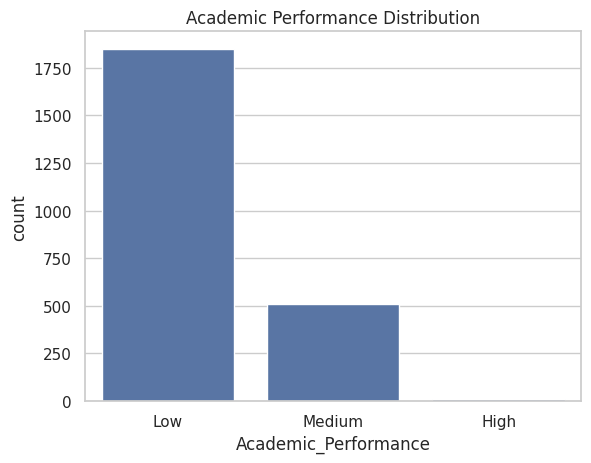

In [ ]:
sns.countplot(x='Academic_Performance', data=data)
plt.title("Academic Performance Distribution")
plt.show()


In [ ]:
X = data.drop(columns=['Academic_Performance'])
y = data['Academic_Performance']


In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


Categorical: Index(['Name', 'Gender', 'Gadget_Name', 'Night_Usage',
       'Notification_Frequency', 'Distraction_Level'],
      dtype='object')
Numerical: Index(['ID', 'Age', 'Gadget_Checks_Per_Day', 'Apps_Used_Daily',
       'Anxiety_Level', 'Depression_Level', 'Parental_Control',
       'Social_Interactions', 'Screen_Time_Before_Bed', 'Instagram_Hours',
       'Snapchat_Hours', 'WhatsApp_Hours', 'YouTube_Social_Hours',
       'Telegram_Hours', 'Twitter_Hours', 'Facebook_Hours',
       'YouTube_Learning_Hours', 'Coursera_Hours', 'Udemy_Hours',
       'Google_Classroom_Hours', 'Khan_Academy_Hours', 'Byjus_Hours',
       'Game_Hours', 'Educational_Game_Hours', 'Addiction_Level',
       'Time_on_Education', 'Time_on_Gaming', 'Time_on_Social_Media',
       'Daily_Usage_Hours', 'Family_Communication'],
      dtype='object')


In [ ]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

print("Missing Values After Handling:\n", X.isnull().sum())


Missing Values After Handling:
 ID                        0
Name                      0
Age                       0
Gender                    0
Gadget_Name               0
Gadget_Checks_Per_Day     0
Apps_Used_Daily           0
Anxiety_Level             0
Depression_Level          0
Parental_Control          0
Social_Interactions       0
Screen_Time_Before_Bed    0
Night_Usage               0
Notification_Frequency    0
Instagram_Hours           0
Snapchat_Hours            0
WhatsApp_Hours            0
YouTube_Social_Hours      0
Telegram_Hours            0
Twitter_Hours             0
Facebook_Hours            0
YouTube_Learning_Hours    0
Coursera_Hours            0
Udemy_Hours               0
Google_Classroom_Hours    0
Khan_Academy_Hours        0
Byjus_Hours               0
Game_Hours                0
Educational_Game_Hours    0
Distraction_Level         0
Addiction_Level           0
Time_on_Education         0
Time_on_Gaming            0
Time_on_Social_Media      0
Daily_Usage_Hour

                ID          Age  Gadget_Checks_Per_Day  Apps_Used_Daily  \
count  2373.000000  2373.000000            2373.000000      2373.000000   
mean   1500.114201    15.999157              83.530131        12.648125   
std     871.296797     1.984127              37.865560         4.607219   
min       3.000000    13.000000              20.000000         5.000000   
25%     744.000000    14.000000              51.000000         9.000000   
50%    1518.000000    16.000000              83.000000        13.000000   
75%    2257.000000    18.000000             116.000000        17.000000   
max    3000.000000    19.000000             150.000000        20.000000   

       Anxiety_Level  Depression_Level  Parental_Control  Social_Interactions  \
count    2373.000000       2373.000000       2373.000000          2373.000000   
mean        5.614412          5.461441          0.512432             5.101981   
std         2.903318          2.866310          0.499951             3.151147   


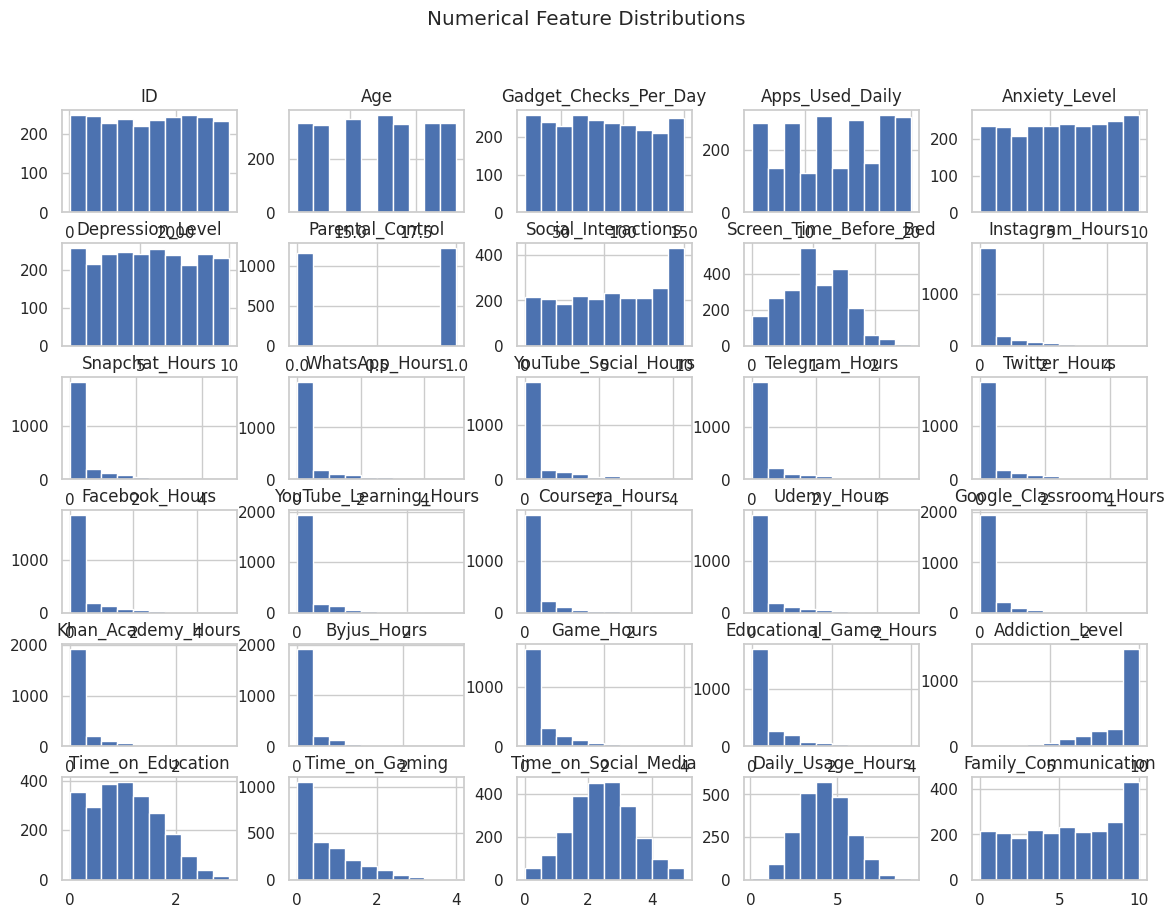

In [ ]:
print(X.describe())

X[numerical_cols].hist(figsize=(14,10))
plt.suptitle("Numerical Feature Distributions")
plt.show()


In [ ]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le


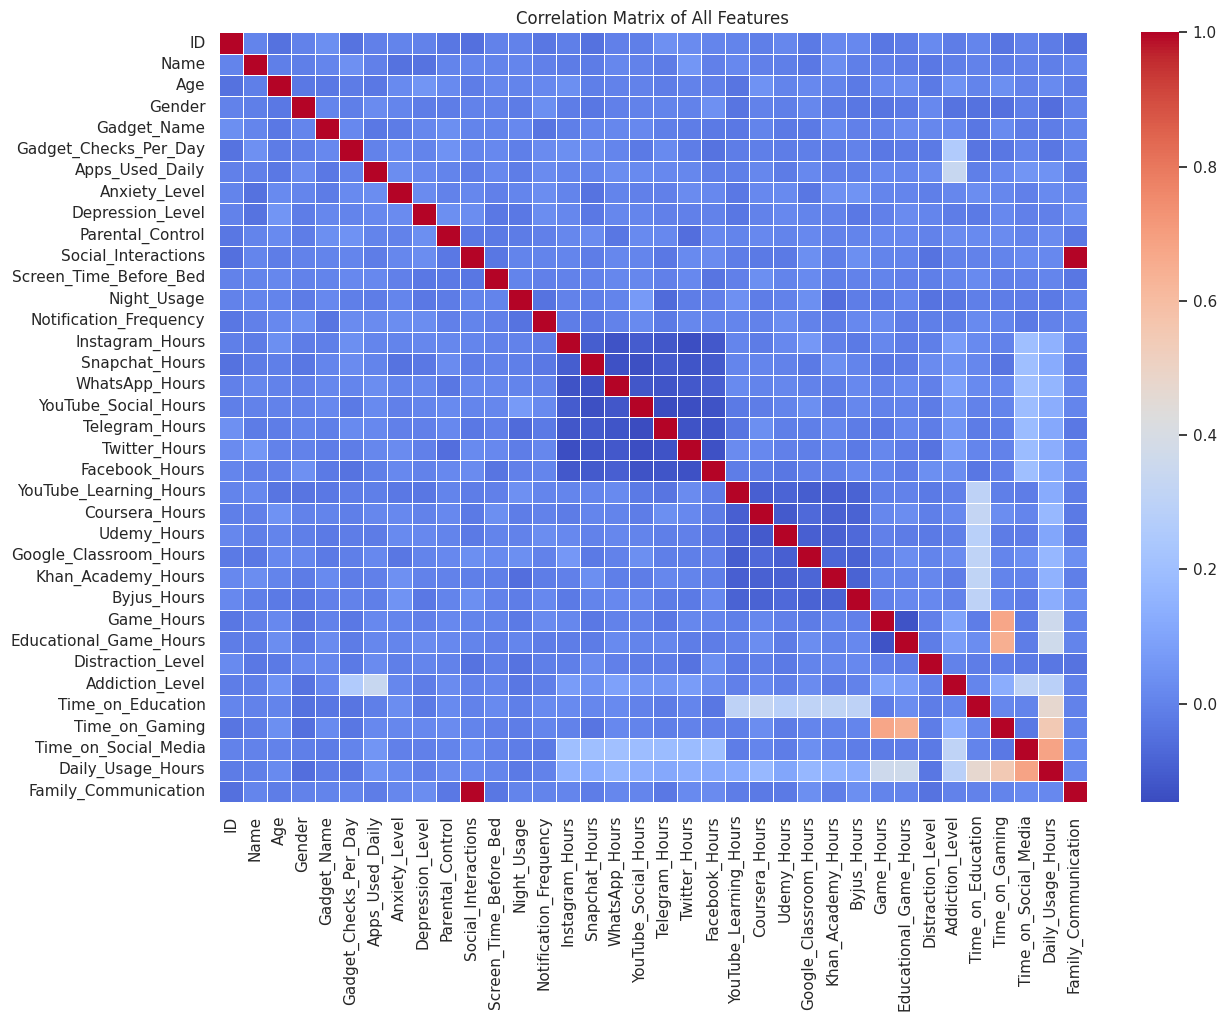

In [ ]:
# =============================================================
# STEP 9A: FEATURE CORRELATION MATRIX
# =============================================================

correlation_matrix = X.corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Matrix of All Features")
plt.show()


In [ ]:
# =============================================================
# STEP 9B: TARGET ENCODING FOR CORRELATION ANALYSIS
# =============================================================

target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y_encoded = y.map(target_mapping)


In [ ]:
# =============================================================
# STEP 9C: FEATURE CORRELATION WITH TARGET
# =============================================================

combined_df = pd.concat(
    [X, y_encoded.rename('Academic_Performance')],
    axis=1
)

target_correlation = combined_df.corr()['Academic_Performance'] \
    .sort_values(ascending=False)

print("Correlation of Features with Academic Performance:\n")
print(target_correlation)


Correlation of Features with Academic Performance:

Academic_Performance      1.000000
Time_on_Education         0.442409
Social_Interactions       0.383992
Family_Communication      0.383992
Byjus_Hours               0.165218
Google_Classroom_Hours    0.160112
YouTube_Learning_Hours    0.152261
Coursera_Hours            0.120581
Khan_Academy_Hours        0.109137
Udemy_Hours               0.105364
Distraction_Level         0.028049
ID                        0.013446
Notification_Frequency    0.013238
Name                      0.009466
Gender                    0.006646
Anxiety_Level             0.006416
Depression_Level          0.005184
Age                       0.003671
Night_Usage              -0.001354
Gadget_Name              -0.011933
Parental_Control         -0.012071
Gadget_Checks_Per_Day    -0.018289
Apps_Used_Daily          -0.036915
Screen_Time_Before_Bed   -0.037035
Instagram_Hours          -0.055900
Facebook_Hours           -0.058893
WhatsApp_Hours           -0.062690
You

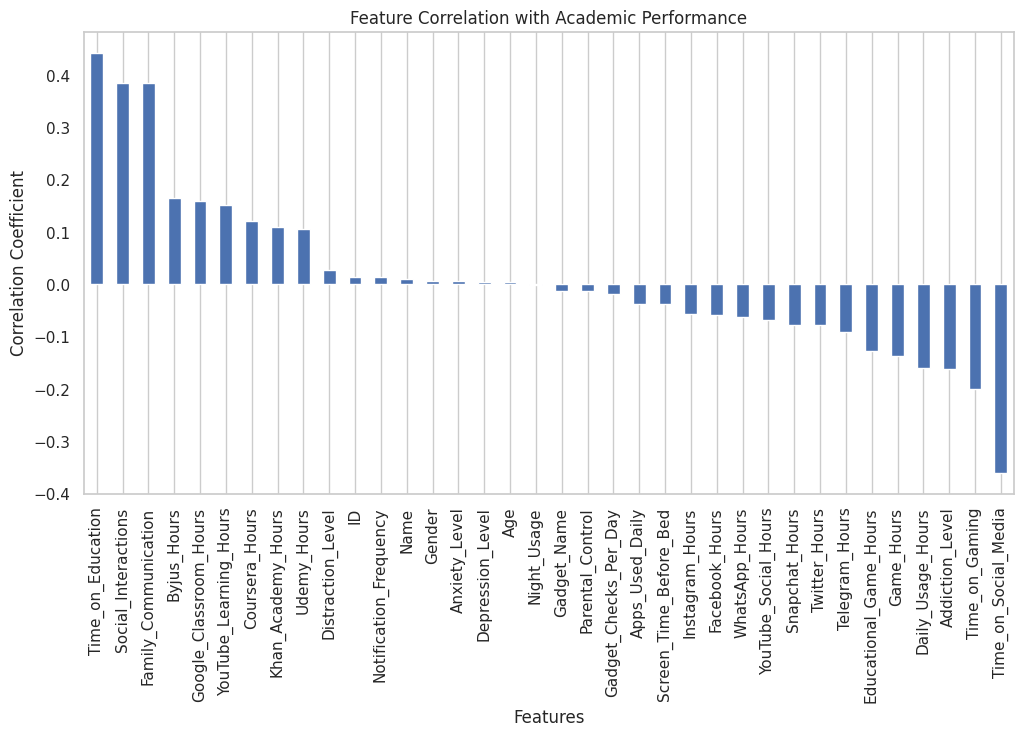

In [ ]:
# =============================================================
# STEP 9D: FEATURE vs TARGET CORRELATION VISUALIZATION
# =============================================================

plt.figure(figsize=(12,6))
target_correlation.drop('Academic_Performance').plot(kind='bar')
plt.title("Feature Correlation with Academic Performance")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.grid(axis='y')
plt.show()


In [ ]:
# =============================================================
# STEP 9E: TOP INFLUENCING FEATURES
# =============================================================

top_positive = target_correlation.head(5)
top_negative = target_correlation.tail(5)

print("Top Positive Correlations:\n", top_positive)
print("\nTop Negative Correlations:\n", top_negative)


Top Positive Correlations:
 Academic_Performance    1.000000
Time_on_Education       0.442409
Social_Interactions     0.383992
Family_Communication    0.383992
Byjus_Hours             0.165218
Name: Academic_Performance, dtype: float64

Top Negative Correlations:
 Game_Hours             -0.136788
Daily_Usage_Hours      -0.160110
Addiction_Level        -0.162109
Time_on_Gaming         -0.200497
Time_on_Social_Media   -0.359977
Name: Academic_Performance, dtype: float64


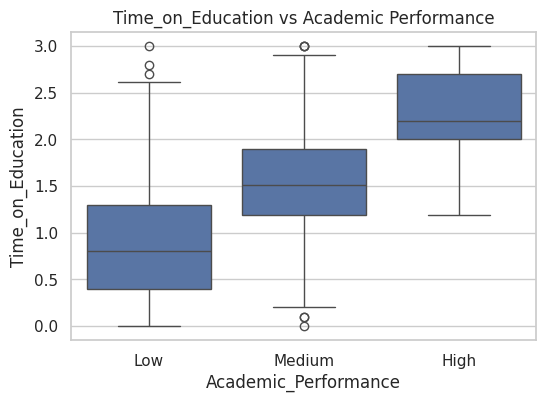

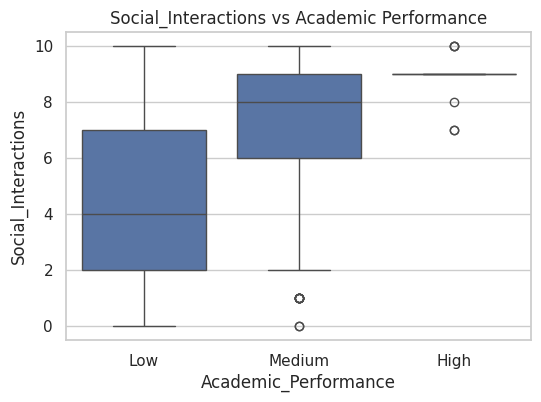

In [ ]:
# =============================================================
# STEP 9F: FEATURE vs TARGET DISTRIBUTION PLOTS
# =============================================================

important_features = top_positive.index[1:3]

for feature in important_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=y, y=X[feature])
    plt.title(f"{feature} vs Academic Performance")
    plt.show()


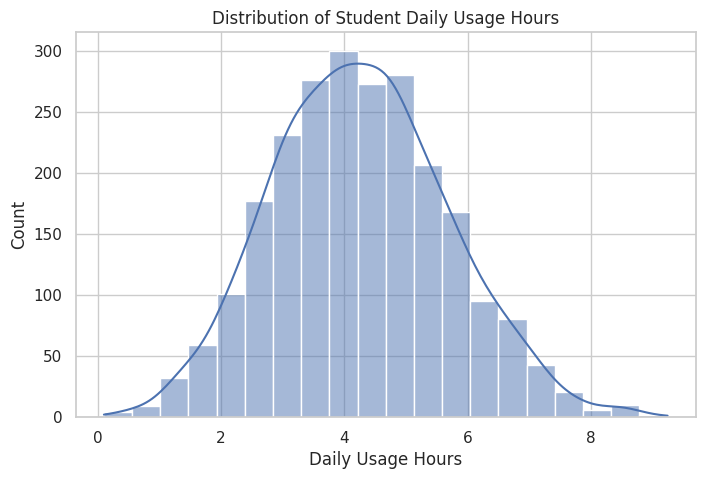

In [ ]:
# ============================================================
# STUDENT BEHAVIOR DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data['Daily_Usage_Hours'],
    bins=20,
    kde=True
)

plt.title("Distribution of Student Daily Usage Hours")

plt.xlabel("Daily Usage Hours")

plt.show()

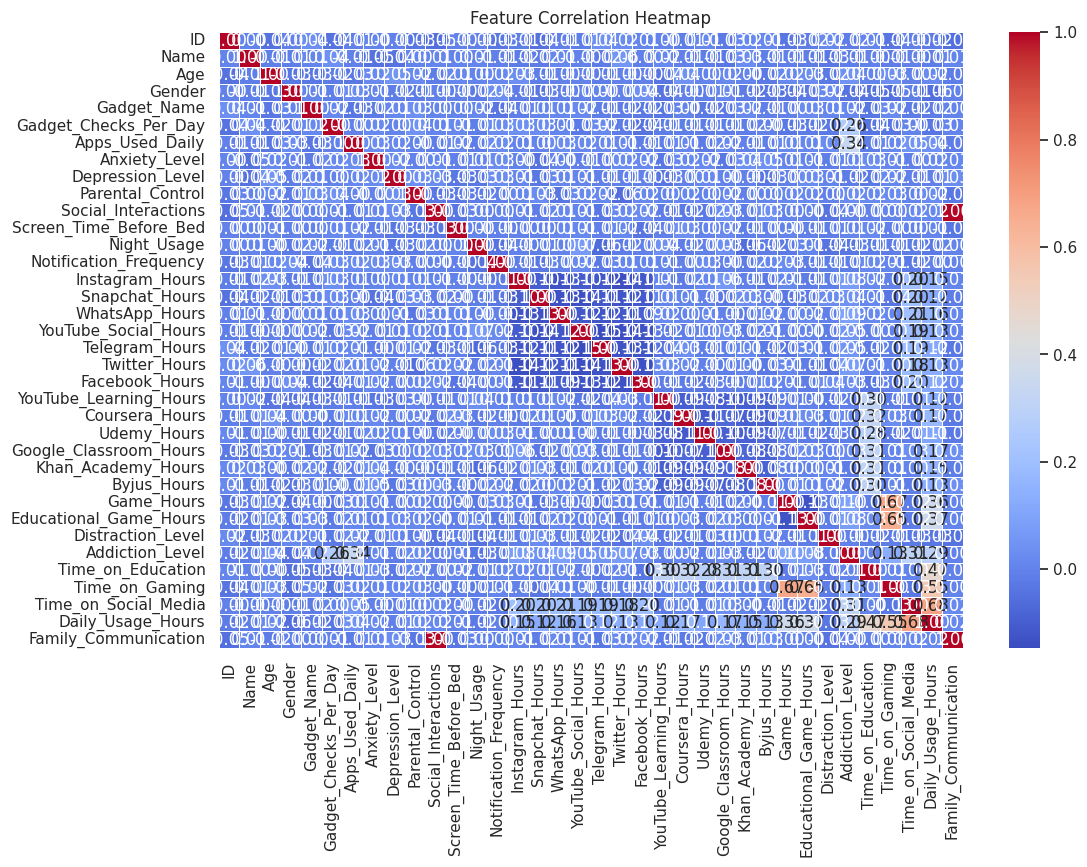

In [ ]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr = X.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

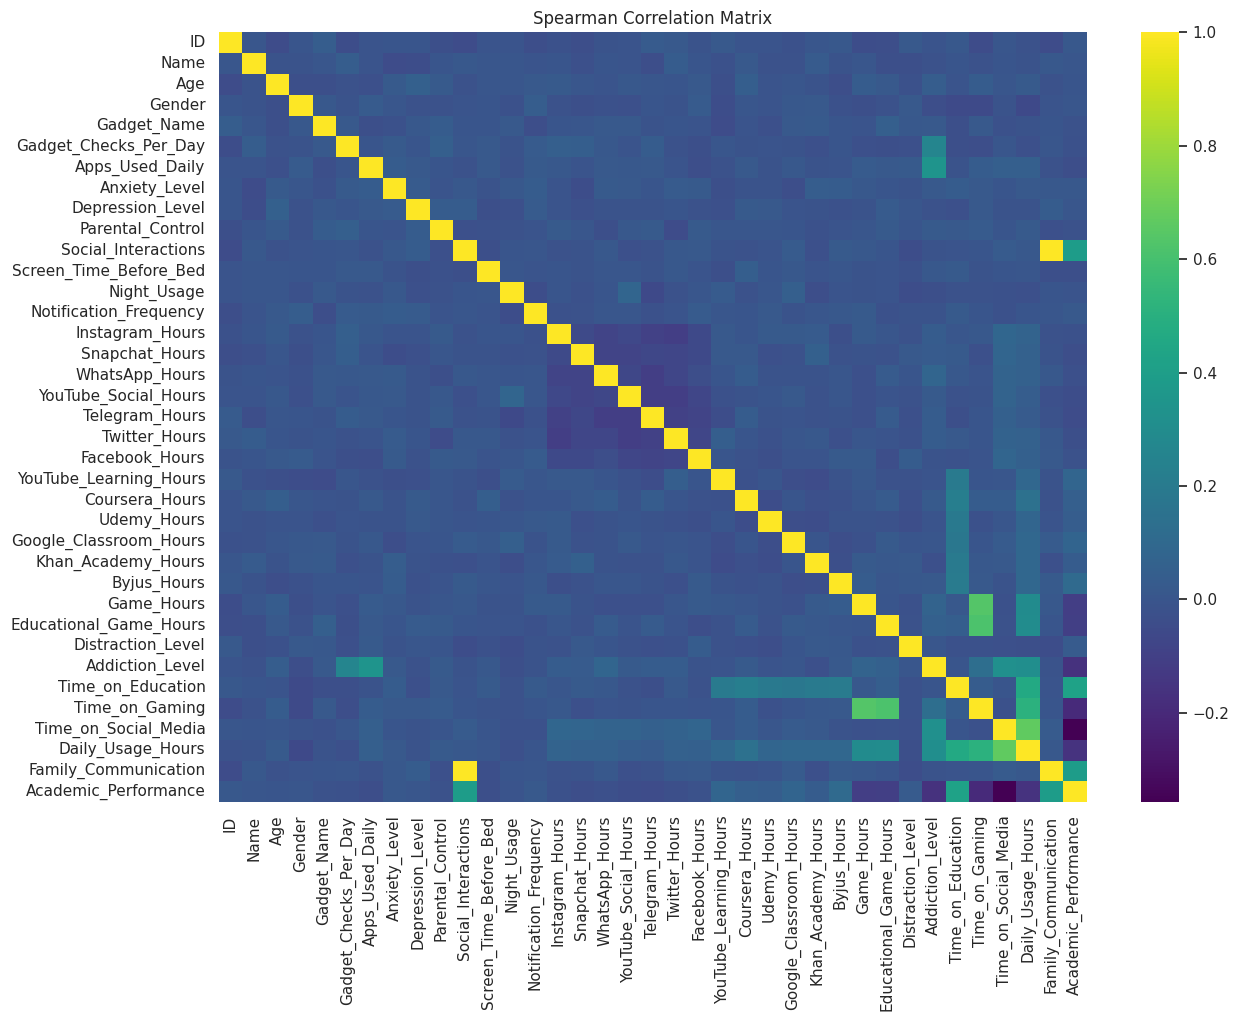

In [ ]:
# =============================================================
# STEP 9G: SPEARMAN CORRELATION MATRIX
# =============================================================

spearman_corr = combined_df.corr(method='spearman')

plt.figure(figsize=(14,10))
sns.heatmap(
    spearman_corr,
    cmap='viridis',
    annot=False
)
plt.title("Spearman Correlation Matrix")
plt.show()


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)


Selected Features: Index(['Social_Interactions', 'YouTube_Learning_Hours',
       'Google_Classroom_Hours', 'Byjus_Hours', 'Addiction_Level',
       'Time_on_Education', 'Time_on_Gaming', 'Time_on_Social_Media',
       'Daily_Usage_Hours', 'Family_Communication'],
      dtype='object')


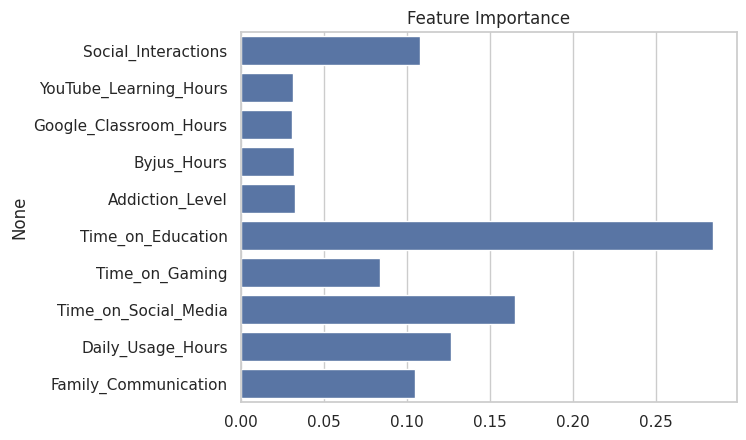

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_selected, y)

importances = rf.feature_importances_

sns.barplot(x=importances, y=selected_features)
plt.title("Feature Importance")
plt.show()


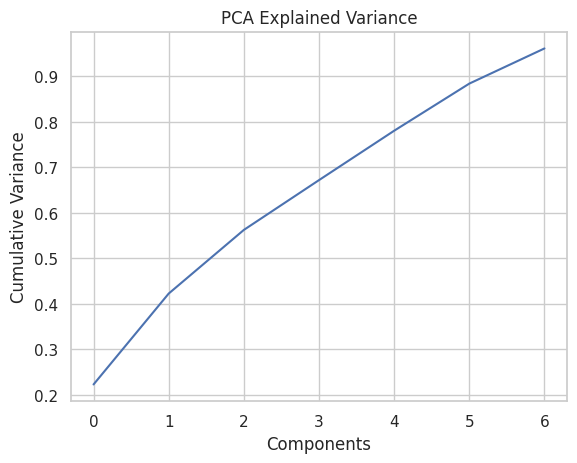

In [ ]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_selected)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.show()


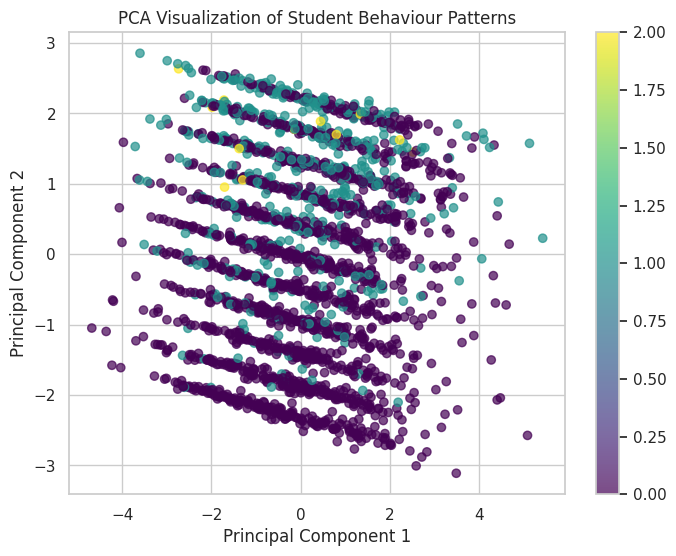

In [ ]:
# ============================================================
# PCA VISUALIZATION
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_encoded,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization of Student Behaviour Patterns")

plt.colorbar()

plt.show()

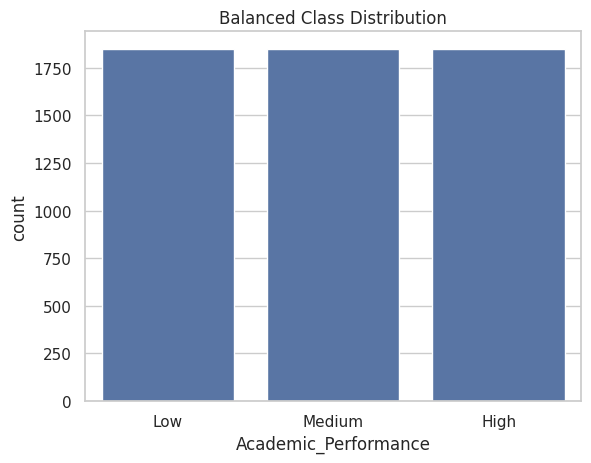

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=2)
X_balanced, y_balanced = smote.fit_resample(X_pca, y)

sns.countplot(x=y_balanced)
plt.title("Balanced Class Distribution")
plt.show()

In [ ]:
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y_balanced_encoded = y_balanced.map(target_mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced_encoded,
    test_size=0.2,
    stratify=y_balanced_encoded,
    random_state=42
)

In [ ]:
pip install shap

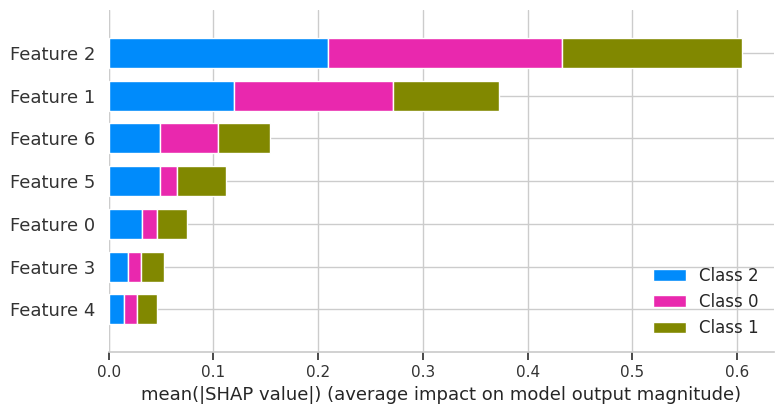

In [ ]:
# ============================================================
# SHAP FEATURE IMPORTANCE
# ============================================================

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
import pandas as pd # Import pandas for feature names

# --- Data and Preprocessing for self-containment ---
# Ensure `data` is loaded if not already from previous cell
data = pd.read_csv('/content/final_trending_platform_dataset.csv')

# Recalculate derived features (from cell K14rqqqHB2Vq)
education_cols = [
    'YouTube_Learning_Hours', 'Coursera_Hours', 'Udemy_Hours',
    'Google_Classroom_Hours', 'Khan_Academy_Hours', 'Byjus_Hours'
]
data['Time_on_Education'] = data[education_cols].sum(axis=1)

gaming_cols = ['Game_Hours', 'Educational_Game_Hours']
data['Time_on_Gaming'] = data[gaming_cols].sum(axis=1)

social_media_cols = [
    'Instagram_Hours', 'Snapchat_Hours', 'WhatsApp_Hours',
    'YouTube_Social_Hours', 'Telegram_Hours', 'Twitter_Hours',
    'Facebook_Hours'
]
data['Time_on_Social_Media'] = data[social_media_cols].sum(axis=1)

all_hours_cols = education_cols + gaming_cols + social_media_cols
data['Daily_Usage_Hours'] = data[all_hours_cols].sum(axis=1)
data['Family_Communication'] = data['Social_Interactions']

def compute_academic_performance(row):
    score = (
        row['Time_on_Education'] * 0.6
        - row['Time_on_Gaming'] * 0.2
        - row['Time_on_Social_Media'] * 0.2
        - row['Daily_Usage_Hours'] * 0.1
        + row['Family_Communication'] * 0.1
    )
    if score >= 1.5:
        return 'High'
    elif score >= 0.5:
        return 'Medium'
    else:
        return 'Low'
data['Academic_Performance'] = data.apply(compute_academic_performance, axis=1)

# Define X and y (from cell wxTZNM6jB2PC)
X = data.drop(columns=['Academic_Performance'])
y = data['Academic_Performance']

# Identify categorical and numerical columns (from cell TVSDtgbCB2MM)
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns

# Impute missing values (from cell Db5GJqB6B2I0)
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# Encode categorical features (from cell _xsTUkDVB2C7)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
# --- End of Data and Preprocessing ---

# --- Re-execute preprocessing steps for self-containment ---
# 1. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Select K Best features
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)

# 3. Apply PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_selected)
# --- End of re-executed preprocessing steps ---

# SMOTE for balancing classes
smote = SMOTE(random_state=42, k_neighbors=2)
X_balanced, y_balanced = smote.fit_resample(X_pca, y)

# Re-performing train-test split
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y_balanced_encoded = y_balanced.map(target_mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced_encoded,
    test_size=0.2,
    stratify=y_balanced_encoded,
    random_state=42
)

# Define and fit the RandomForestClassifier as it would be for the ensemble
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)
rf.fit(X_train, y_train) # Fit the model to the training data

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

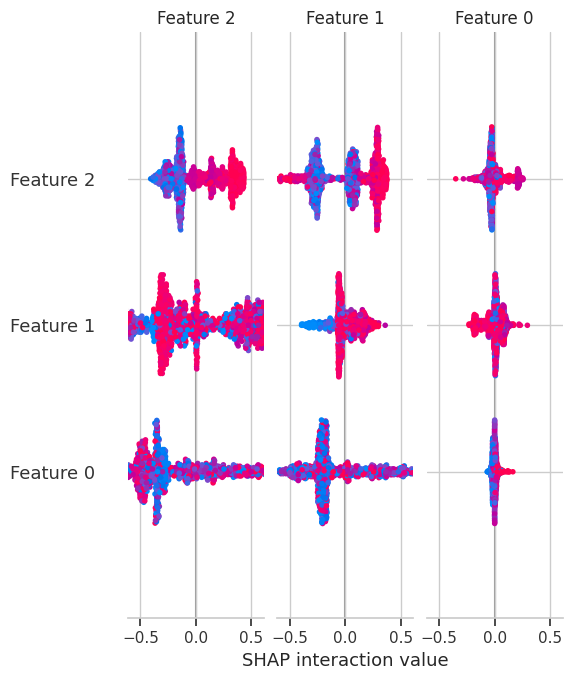

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
# ============================================================
# IMPORT MODELS
# ============================================================

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# BASE MODELS
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

svm = SVC(
    kernel='rbf',
    C=10,
    probability=True,
    random_state=42
)

dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
# ============================================================
# STACKING MODEL
# ============================================================

base_models = [
    ('rf', rf),
    ('svm', svm),
    ('dt', dt),
    ('knn', knn),
    ('xgb', xgb)
]

meta_model = LogisticRegression(max_iter=1000)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=True
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

print("STACKING ACCURACY:", accuracy_score(y_test, stack_pred))

STACKING ACCURACY: 0.9801801801801802


In [ ]:
# ============================================================
# SOFT VOTING ENSEMBLE
# ============================================================

voting_model = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('dt', dt),
        ('knn', knn),
        ('xgb', xgb)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)

vote_pred = voting_model.predict(X_test)

print("VOTING ACCURACY:", accuracy_score(y_test, vote_pred))

VOTING ACCURACY: 0.972072072072072


In [ ]:
# ============================================================
# FINAL FUSION PREDICTION
# ============================================================

import numpy as np

# The predictions stack_pred and vote_pred are already numerical (0, 1, 2)
# corresponding to 'Low', 'Medium', 'High'.
# No need to remap them using target_mapping here.

# Perform the averaging on numerical predictions directly
final_pred_numeric = np.round((stack_pred + vote_pred) / 2).astype(int)

# Create a reverse mapping to convert numerical predictions back to original labels
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2} # Keep target_mapping defined for reverse mapping
reverse_target_mapping = {v: k for k, v in target_mapping.items()}
final_pred = np.array([reverse_target_mapping[pred] for pred in final_pred_numeric])

# Use y_test (numerical) and final_pred_numeric (numerical) for metrics
final_accuracy = accuracy_score(y_test, final_pred_numeric)

print("\nFINAL FUSION ACCURACY:", final_accuracy)

print("\nClassification Report\n")
print(classification_report(y_test, final_pred_numeric))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, final_pred_numeric))


FINAL FUSION ACCURACY: 0.9792792792792793

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       370
           1       0.96      0.98      0.97       370
           2       1.00      1.00      1.00       370

    accuracy                           0.98      1110
   macro avg       0.98      0.98      0.98      1110
weighted avg       0.98      0.98      0.98      1110


Confusion Matrix

[[354  16   0]
 [  6 363   1]
 [  0   0 370]]


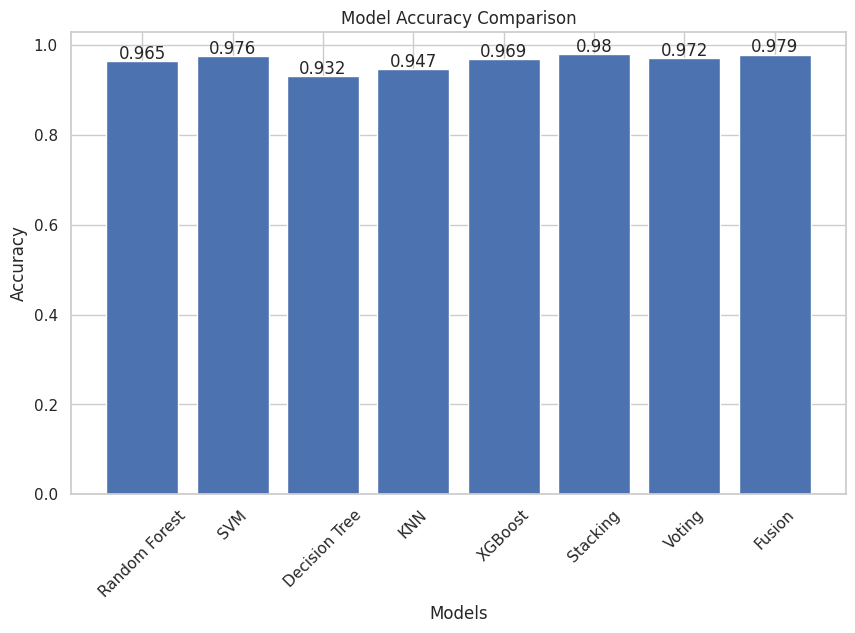

In [ ]:
# ============================================================
# MODEL ACCURACY COMPARISON
# ============================================================

import matplotlib.pyplot as plt

models = ['Random Forest','SVM','Decision Tree','KNN','XGBoost','Stacking','Voting','Fusion']

# Fit individual models on X_train, y_train for scoring
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)
knn.fit(X_train, y_train)
xgb.fit(X_train, y_train)

accuracies = [
    rf.score(X_test,y_test),
    svm.score(X_test,y_test),
    dt.score(X_test,y_test),
    knn.score(X_test,y_test),
    xgb.score(X_test,y_test),
    accuracy_score(y_test, stack_pred),
    accuracy_score(y_test, vote_pred),
    final_accuracy
]

plt.figure(figsize=(10,6))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)

for i,v in enumerate(accuracies):
    plt.text(i,v+0.005,str(round(v,3)),ha='center')

plt.show()

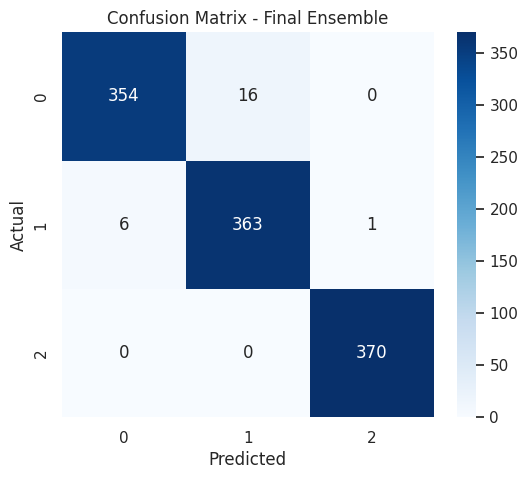

In [ ]:
# ============================================================
# CONFUSION MATRIX HEATMAP
# ============================================================

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_pred_numeric)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Confusion Matrix - Final Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

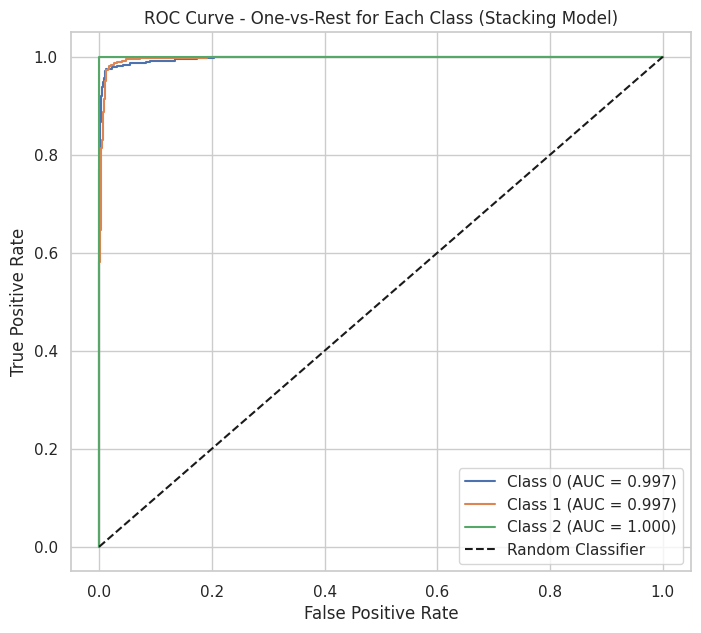

In [ ]:
# ============================================================
# ROC CURVE (MULTICLASS)
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_pred_proba = stack_model.predict_proba(X_test)

# Binarize the true labels for OvR strategy
n_classes = len(np.unique(y_test))
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2]) # Assuming classes are 0, 1, 2

plt.figure(figsize=(8, 7))

# Plot ROC curve for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One-vs-Rest for Each Class (Stacking Model)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

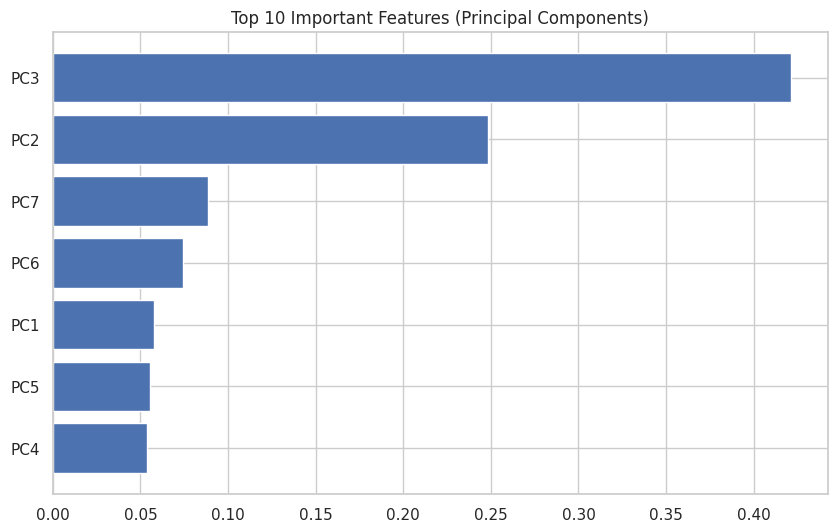

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

import pandas as pd

importances = rf.feature_importances_

# X_train is a numpy array (after PCA and SMOTE), so it doesn't have .columns
# We need to create feature names for the principal components
features = [f'PC{i+1}' for i in range(X_train.shape[1])]

importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':importances
})

importance_df = importance_df.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))

plt.barh(importance_df['Feature'][:10],
         importance_df['Importance'][:10])

plt.title("Top 10 Important Features (Principal Components)")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# ============================================================
# CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(stack_model, X_train, y_train, cv=cv)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.98085586 0.97635135 0.98308906 0.97632469 0.97181511]
Mean CV Accuracy: 0.9776872137075069


In [ ]:
import joblib

joblib.dump(stack_model, "student_performance_ensemble.pkl")

print("Model saved successfully")

Model saved successfully


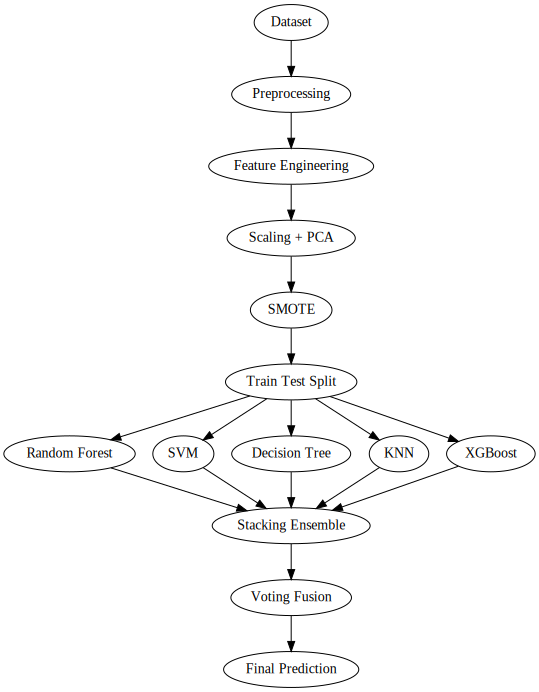

In [ ]:
from graphviz import Digraph

dot = Digraph()

dot.node('A','Dataset')
dot.node('B','Preprocessing')
dot.node('C','Feature Engineering')
dot.node('D','Scaling + PCA')
dot.node('E','SMOTE')
dot.node('F','Train Test Split')

dot.node('G','Random Forest')
dot.node('H','SVM')
dot.node('I','Decision Tree')
dot.node('J','KNN')
dot.node('K','XGBoost')

dot.node('L','Stacking Ensemble')
dot.node('M','Voting Fusion')
dot.node('N','Final Prediction')

dot.edges(['AB','BC','CD','DE','EF'])

dot.edges(['FG','FH','FI','FJ','FK'])

dot.edges(['GL','HL','IL','JL','KL'])

dot.edge('L','M')
dot.edge('M','N')

dot

In [ ]:
dot.format = 'jpg'   # Set output format to JPG
dot.render('travel_model_pipeline', view=True)

'travel_model_pipeline.jpg'